# 10 — Training SVM and Softmax Linear Classifiers

Multiclass SVM and softmax cross-entropy use the same linear score function but turn its scores into different losses and gradients. This notebook trains both under controlled conditions and examines what those differences mean in practice.

## Learning objectives

- compare SVM and softmax loss and score gradients on identical scores;
- reuse one SGD loop with interchangeable loss functions;
- design a fair controlled training comparison;
- compare validation accuracy and per-class behavior;
- interpret score gaps, probabilities, and learned templates carefully;
- distinguish a controlled experiment from hyperparameter selection.

In [37]:
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

## 1. Same scores, different objectives

For one example, multiclass SVM uses

$$L_{SVM}=\sum_{j\ne y}\max(0,s_j-s_y+\Delta),$$

while softmax cross-entropy uses

$$L_{softmax}=-s_y+\log\sum_j e^{s_j}.$$

SVM depends on which margins are active. Softmax depends smoothly on all class probabilities. Their numeric loss values live on different scales and should not be compared as if a lower SVM number directly means a better model than the same softmax number.

### Exercise 1 — Compare one example

For scores `[3, 1, 0]`, correct class `0`, and $\Delta=1$:

1. calculate both losses;
2. calculate both score-gradient vectors;
3. explain why SVM has zero gradient while softmax still has a small gradient.

In [38]:
# Store one score for each of the three classes.
comparison_scores = np.array([3.0, 1.0, 0.0])
# Class 0 is the correct class for this example.
comparison_label = 0
# Use the standard multiclass SVM margin requirement.
delta = 1.0

# Calculate every class margin relative to the correct-class score.
svm_margins = np.maximum(
    0.0,
    comparison_scores - comparison_scores[comparison_label] + delta,
)
# The correct class is excluded from the SVM loss.
svm_margins[comparison_label] = 0.0
# Sum the remaining nonnegative margins to obtain one-example loss.
svm_loss_one = float(svm_margins.sum())

# Mark each active incorrect margin with 1 and each inactive margin with 0.
svm_d_scores_one = (svm_margins > 0).astype(np.float64)
# Each active margin contributes -1 to the correct-class score gradient.
svm_d_scores_one[comparison_label] = -svm_d_scores_one.sum()

# Shift all scores by their maximum to avoid exponential overflow.
shifted_scores = comparison_scores - comparison_scores.max()
# Exponentiate the shifted scores to obtain positive unnormalized values.
exp_scores = np.exp(shifted_scores)
# Add those values to obtain the softmax normalization constant.
sum_exp_scores = exp_scores.sum()
# Use stable log-sum-exp minus the shifted correct score for cross-entropy.
softmax_loss_one = float(
    np.log(sum_exp_scores) - shifted_scores[comparison_label]
)
# Normalize exponentials so the class probabilities sum to one.
softmax_probabilities_one = exp_scores / sum_exp_scores
# Copy probabilities because the gradient must not modify saved probabilities.
softmax_d_scores_one = softmax_probabilities_one.copy()
# Subtract the one-hot target at the correct class: dS = P - Y.
softmax_d_scores_one[comparison_label] -= 1.0

# The correct score exceeds both incorrect scores by more than delta.
assert np.isclose(svm_loss_one, 0.0)
# With no active margins, every SVM score derivative must be zero.
np.testing.assert_allclose(svm_d_scores_one, np.zeros(3))
# Softmax loss remains positive for every finite score separation.
assert softmax_loss_one > 0
# The correct-class gradient is negative, so gradient descent raises its score.
assert softmax_d_scores_one[comparison_label] < 0
# Incorrect-class gradients are positive, so gradient descent lowers their scores.
assert np.all(np.delete(softmax_d_scores_one, comparison_label) > 0)
# A zero gradient sum reflects invariance to a shared shift of all scores.
assert np.isclose(softmax_d_scores_one.sum(), 0.0)
# Display the two losses and score-gradient vectors for comparison.
print("SVM:    ", svm_loss_one, svm_d_scores_one)
print("Softmax:", softmax_loss_one, softmax_d_scores_one)

SVM:     0.0 [-0.  0.  0.]
Softmax: 0.16984601955628567 [-0.15620527  0.1141952   0.04201007]


demonstrates that SVM stops contributing after its margins are satisfied, while softmax continues encouraging greater correct-class probability.

## 2. Vectorized loss functions with a shared interface

Both functions below accept the same inputs and return `(loss, dW, db)`. This shared interface lets the optimizer remain independent of the particular loss.

The project convention is $L_{reg}=\lambda\sum W^2$, with gradient $2\lambda W$.

In [39]:
def svm_loss_and_gradient(
    X: np.ndarray, y: np.ndarray, W: np.ndarray, b: np.ndarray,
    regularization_strength: float = 0.0, delta: float = 1.0,
) -> tuple[float, np.ndarray, np.ndarray]:
    scores = X @ W.T + b
    correct_scores = scores[np.arange(X.shape[0]), y][:, None]
    margins = np.maximum(0.0, scores - correct_scores + delta)
    margins[np.arange(X.shape[0]), y] = 0.0

    data_loss = margins.sum() / X.shape[0]
    regularization_loss = regularization_strength * np.sum(W * W)

    d_scores = (margins > 0).astype(scores.dtype)
    d_scores[np.arange(X.shape[0]), y] = -d_scores.sum(axis=1)
    d_scores /= X.shape[0]
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)
    return float(data_loss + regularization_loss), dW, db


def softmax_loss_and_gradient(
    X: np.ndarray, y: np.ndarray, W: np.ndarray, b: np.ndarray,
    regularization_strength: float = 0.0,
) -> tuple[float, np.ndarray, np.ndarray]:
    scores = X @ W.T + b
    shifted_scores = scores - scores.max(axis=1, keepdims=True)
    exp_scores = np.exp(shifted_scores)
    sum_exp_scores = exp_scores.sum(axis=1, keepdims=True)
    probabilities = exp_scores / sum_exp_scores

    correct_scores = shifted_scores[np.arange(X.shape[0]), y]
    data_loss = np.mean(np.log(sum_exp_scores[:, 0]) - correct_scores)
    regularization_loss = regularization_strength * np.sum(W * W)

    d_scores = probabilities.copy()
    d_scores[np.arange(X.shape[0]), y] -= 1.0
    d_scores /= X.shape[0]
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)
    return float(data_loss + regularization_loss), dW, db

## 3. Prepare one shared CIFAR-10 split

Both models must use identical training and validation examples and the same training-derived feature mean.

In [40]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
labels_all = np.asarray(dataset.targets, dtype=np.int64)
TRAIN_SIZE = 10_000
VAL_SIZE = 2_000
split_rng = np.random.default_rng(SEED)
permutation = split_rng.permutation(len(dataset.data))
train_indices = permutation[:TRAIN_SIZE]
val_indices = permutation[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]

X_train = dataset.data[train_indices].reshape(TRAIN_SIZE, -1).astype(np.float32) / 255.0
y_train = labels_all[train_indices]
X_val = dataset.data[val_indices].reshape(VAL_SIZE, -1).astype(np.float32) / 255.0
y_val = labels_all[val_indices]
train_mean = X_train.mean(axis=0, keepdims=True)
X_train -= train_mean
X_val -= train_mean
print(X_train.shape, X_val.shape)

(10000, 3072) (2000, 3072)


## 4. One optimizer, interchangeable losses

A well-separated optimizer should only need a callable that supplies loss and gradients. It should not contain `if loss == ...` branches or duplicate training loops.

### Exercise 2 — Implement the generic SGD loop

Use `loss_function(X_batch, y_batch, W, b, regularization_strength)`. Copy the starting parameters, sample without replacement within each minibatch, update `W` and `b`, and return the loss history.

In [41]:
LossFunction = Callable[[np.ndarray, np.ndarray, np.ndarray, np.ndarray, float], tuple[float, np.ndarray, np.ndarray]]


def train_linear_classifier(
    X: np.ndarray, y: np.ndarray, W_start: np.ndarray, b_start: np.ndarray,
    loss_function: LossFunction, *, learning_rate: float,
    regularization_strength: float, batch_size: int, num_iterations: int,
    generator: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, list[float]]:
    """Train a linear classifier using a supplied loss-and-gradient function."""
    W = W_start.copy()
    b = b_start.copy()
    loss_history: list[float] = []

    for _ in range(num_iterations):
        # sample indices and form a minibatch.
        indices = generator.choice(X.shape[0], size=batch_size, replace=False)
        sample_X, sample_y = X[indices], y[indices]
        # evaluate the supplied loss function.
        loss, dW, db = loss_function(
            sample_X, sample_y, W, b, regularization_strength
        )
        # update both parameters and record loss.
        W -= learning_rate * dW
        b -= learning_rate * db
        loss_history.append(loss)

    return W, b, loss_history

## 5. Controlled training comparison

To isolate loss-function behavior, both runs will use:

- identical initial `W` and `b`;
- identical minibatch indices in the same order;
- the same iteration count, batch size, learning rate, and regularization;
- the same train and validation data.

This is controlled, but not necessarily optimal for either loss. Equal hyperparameters do not guarantee equal tuning quality.

### Exercise 3 — Train both models fairly

In [42]:
num_classes = len(CLASS_NAMES)
num_features = X_train.shape[1]
initialization_rng = np.random.default_rng(SEED)
W_initial = initialization_rng.normal(0.0, 1e-3, size=(num_classes, num_features)).astype(np.float32)
b_initial = np.zeros(num_classes, dtype=np.float32)

training_config = {
    "learning_rate": 0.1,
    "regularization_strength": 1e-3,
    "batch_size": 256,
    "num_iterations": 500,
}

# train SVM and softmax from the same parameters.
# Recreate np.random.default_rng(SEED + 1) for each run.
W_svm, b_svm, svm_loss_history = train_linear_classifier(
    X_train, y_train, W_initial, b_initial, svm_loss_and_gradient,
    learning_rate=training_config["learning_rate"],
    regularization_strength=training_config["regularization_strength"],
    batch_size=training_config["batch_size"],
    num_iterations=training_config["num_iterations"],
    generator=np.random.default_rng(SEED + 1),
)
W_softmax, b_softmax, softmax_loss_history = train_linear_classifier(
    X_train, y_train, W_initial, b_initial, softmax_loss_and_gradient,
    learning_rate=training_config["learning_rate"],
    regularization_strength=training_config["regularization_strength"],
    batch_size=training_config["batch_size"],
    num_iterations=training_config["num_iterations"],
    generator=np.random.default_rng(SEED + 1),
)

assert len(svm_loss_history) == training_config["num_iterations"]
assert len(softmax_loss_history) == training_config["num_iterations"]
assert np.all(np.isfinite(svm_loss_history))
assert np.all(np.isfinite(softmax_loss_history))

## 6. Compare optimization curves correctly

Plot both histories, but do not interpret their vertical values as a head-to-head measure: the loss definitions and natural scales differ. Within each curve, ask whether its own objective decreases and stabilizes.

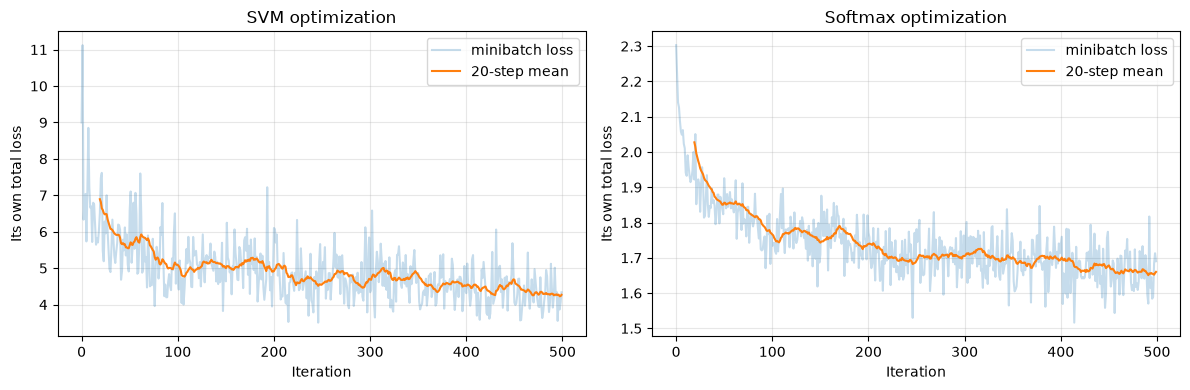

In [43]:
def moving_average(values: list[float], window: int = 20) -> np.ndarray:
    values_array = np.asarray(values, dtype=np.float64)
    return np.convolve(values_array, np.ones(window) / window, mode="valid")


window = 20
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, history, name in [
    (axes[0], svm_loss_history, "SVM"),
    (axes[1], softmax_loss_history, "Softmax"),
]:
    ax.plot(history, alpha=0.25, label="minibatch loss")
    ax.plot(np.arange(window - 1, len(history)), moving_average(history, window), label="20-step mean")
    ax.set(title=f"{name} optimization", xlabel="Iteration", ylabel="Its own total loss")
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

## 7. Validation accuracy and per-class recall

Overall accuracy can hide class-specific behavior. Per-class recall asks: among validation examples whose true class is $c$, what fraction did the model correctly recognize?

### Exercise 4 — Compute overall and per-class results

In [44]:
def predict_linear(X: np.ndarray, W: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.argmax(X @ W.T + b, axis=1)


def per_class_recall(labels: np.ndarray, predictions: np.ndarray, num_classes: int) -> np.ndarray:
    # compute correct / total separately for every true class.
    correct_counts = np.zeros(num_classes, dtype=np.int64)
    total_counts = np.zeros(num_classes, dtype=np.int64)
    for class_index in range(num_classes):
        class_mask = (labels == class_index)
        total_counts[class_index] = np.sum(class_mask)
        correct_counts[class_index] = np.sum(predictions[class_mask] == class_index)
    return correct_counts / total_counts


svm_predictions = predict_linear(X_val, W_svm, b_svm)
softmax_predictions = predict_linear(X_val, W_softmax, b_softmax)
svm_accuracy = np.mean(svm_predictions == y_val)
softmax_accuracy = np.mean(softmax_predictions == y_val)
svm_recall = per_class_recall(y_val, svm_predictions, num_classes)
softmax_recall = per_class_recall(y_val, softmax_predictions, num_classes)

print(f"SVM validation accuracy:     {svm_accuracy:.3f}")
print(f"Softmax validation accuracy: {softmax_accuracy:.3f}")
assert svm_accuracy > 0.20 and softmax_accuracy > 0.20

SVM validation accuracy:     0.320
Softmax validation accuracy: 0.408


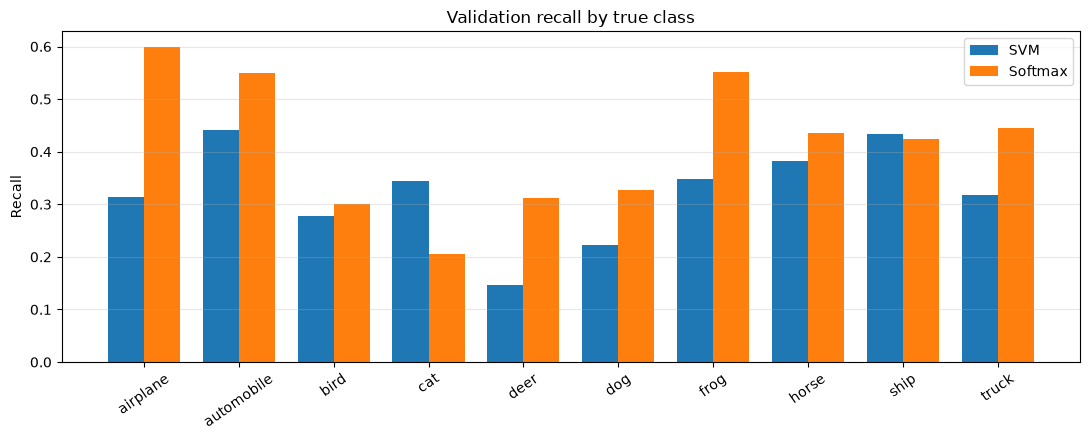

In [45]:
x = np.arange(num_classes)
width = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - width / 2, svm_recall, width, label="SVM")
ax.bar(x + width / 2, softmax_recall, width, label="Softmax")
ax.set(xticks=x, xticklabels=CLASS_NAMES, ylabel="Recall", title="Validation recall by true class")
ax.tick_params(axis="x", rotation=35)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 8. Score gaps and probability interpretation

For each example, define the top-two score gap as the highest score minus the second-highest score. A larger gap means the winner is separated more strongly in that model's own score scale.

Softmax converts scores into normalized probabilities. SVM training does not learn calibrated probabilities, and applying softmax afterward would be an extra interpretation—not part of its training objective. Even softmax-trained probabilities are not automatically calibrated.

### Exercise 5 — Compare correct and incorrect score gaps

Implement `top_two_gap`, then compare median gaps for correctly and incorrectly classified validation examples. Interpret gaps within each model; do not assume one model's raw score units equal the other's.

In [49]:
def top_two_gap(scores: np.ndarray) -> np.ndarray:
    """Return largest minus second-largest score for each row."""
    sorted_scores = np.sort(scores, axis=1)
    return sorted_scores[:, -1] - sorted_scores[:, -2]


for name, W, b, predictions in [
    ("SVM", W_svm, b_svm, svm_predictions),
    ("Softmax", W_softmax, b_softmax, softmax_predictions),
]:
    scores = X_val @ W.T + b
    gaps = top_two_gap(scores)
    correct = predictions == y_val
    print(
        f"{name:7s}: median correct gap={np.median(gaps[correct]):.3f}, "
        f"median incorrect gap={np.median(gaps[~correct]):.3f}"
    )

SVM    : median correct gap=0.751, median incorrect gap=0.506
Softmax: median correct gap=0.661, median incorrect gap=0.381


In [50]:
softmax_scores = X_val @ W_softmax.T + b_softmax
(np.exp(softmax_scores[0:10]) / np.sum(np.exp(softmax_scores[0:10]), axis=1, keepdims=True)).round(2)

array([[0.86, 0.01, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.12, 0.01],
       [0.02, 0.02, 0.08, 0.41, 0.03, 0.19, 0.04, 0.04, 0.07, 0.1 ],
       [0.08, 0.04, 0.16, 0.05, 0.32, 0.03, 0.04, 0.22, 0.02, 0.03],
       [0.  , 0.04, 0.05, 0.32, 0.04, 0.21, 0.26, 0.04, 0.  , 0.02],
       [0.02, 0.03, 0.05, 0.08, 0.25, 0.18, 0.13, 0.17, 0.05, 0.03],
       [0.15, 0.07, 0.09, 0.06, 0.09, 0.3 , 0.02, 0.06, 0.12, 0.03],
       [0.31, 0.07, 0.03, 0.05, 0.01, 0.07, 0.01, 0.02, 0.4 , 0.04],
       [0.42, 0.1 , 0.05, 0.02, 0.01, 0.  , 0.02, 0.01, 0.2 , 0.18],
       [0.2 , 0.03, 0.18, 0.11, 0.08, 0.17, 0.05, 0.05, 0.1 , 0.03],
       [0.47, 0.07, 0.07, 0.01, 0.03, 0.02, 0.01, 0.04, 0.24, 0.03]],
      dtype=float32)

## 9. Compare learned templates

Display corresponding class templates side by side. Normalize every template separately for visibility, so compare spatial and color patterns—not absolute intensity across panels.

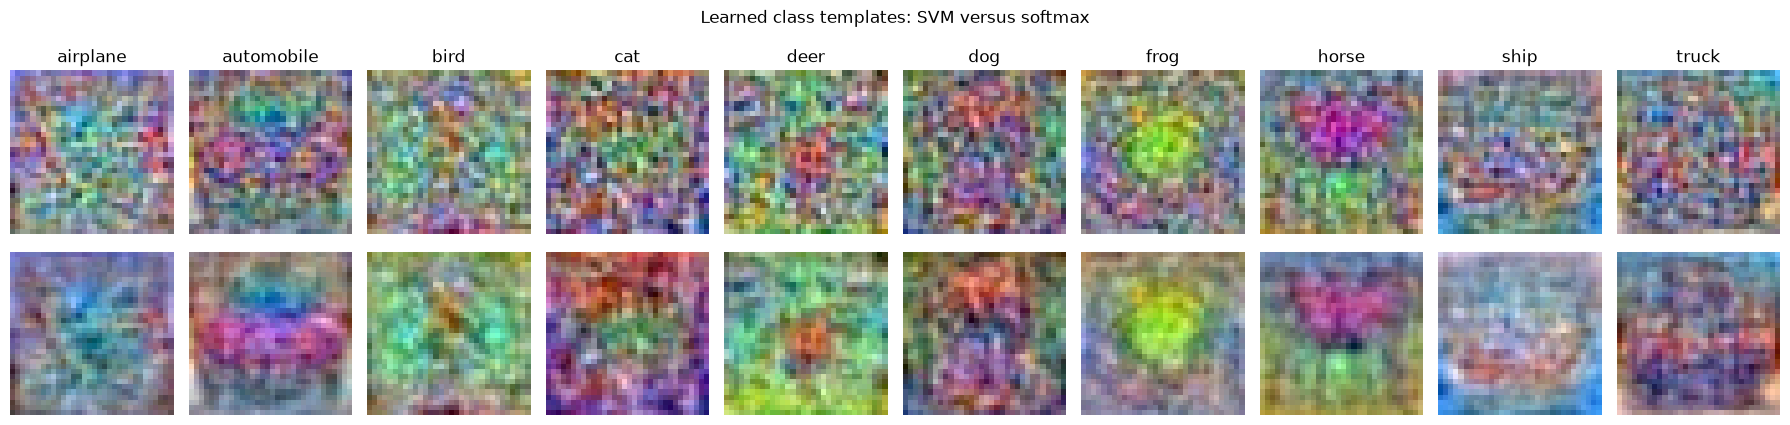

In [51]:
fig, axes = plt.subplots(2, num_classes, figsize=(18, 4.5))
for row, (name, W) in enumerate([("SVM", W_svm), ("Softmax", W_softmax)]):
    for class_index in range(num_classes):
        template = W[class_index].reshape(32, 32, 3)
        display = template - template.min()
        display /= max(display.max(), 1e-12)
        axes[row, class_index].imshow(display)
        axes[row, class_index].axis("off")
        axes[row, class_index].set_title(
            CLASS_NAMES[class_index] if row == 0 else ""
        )
    axes[row, 0].set_ylabel(name, fontsize=12)
fig.suptitle("Learned class templates: SVM versus softmax")
fig.tight_layout()
plt.show()

## Reflection

Add a Markdown cell answering:

1. Why can SVM have zero gradient for an example while softmax still has a nonzero gradient?
2. Why should SVM and softmax loss magnitudes not be compared directly?
3. Which parts of training are loss-specific, and which are shared?
4. Why were identical initialization and minibatch sequences important?
5. Why does equal learning rate and regularization not establish which loss can perform best?
6. What did overall accuracy omit that per-class recall revealed?
7. How did score gaps differ between correct and incorrect predictions?
8. Why should raw score gaps be interpreted within a model rather than directly across models?
9. Can either model's score or probability be assumed calibrated? Why not?
10. What similarities and differences appeared in the learned templates?

Next we will select learning rate and regularization strength systematically using validation and then move the reusable linear-classifier implementation into Python modules with tests.

1. Because of the loss function formula. For SVM its gradient is zero when every incorrect margin is inactive: $s_j-s_y+\Delta\leq0$ . Softmax remains nonzero for finite score separations because its probabilities are never exactly zero or one.
2. Cause they calculated differently. Softmax relies on probabilities, SVM on margins
3. calculating loss and its gradient is loss specific, all other similar
4. We wanted to compare isolated loss-function behavior. Identical initialization and minibatches prevent parameter initialization or batch composition from explaining the observed difference
5. Different loss can have different optimal hyperparameters
6. Overall accuracy does not show how each individual class predicton performs
7. Correctly classified examples had a larger median top-two gap than incorrectly classified examples for both models. 
8. Cause they trained and optimized in different way to satisfy a bit different loss minima. The most important reason is that raw scores have no universal unit. Different objectives, regularization strengths, training histories, and parameter scales can produce different score magnitudes. Therefore, compare gaps within one model unless the models have been meaningfully calibrated or normalized.
9. Neither can be assumed calibrated.

- SVM scores are compatibility values, not probabilities.
- Applying softmax to SVM scores afterward produces normalized numbers, but that does not make them calibrated probabilities.
- A softmax classifier outputs values summing to one, but normalization is not the same as calibration.

A model is calibrated if predictions made with approximately 80% confidence are correct approximately 80% of the time. Calibration must be measured empirically, for example with reliability diagrams or expected calibration error.

10. There are similar patterns but for softmax it seems more gradual and blured.

Both models learn broad class-color and spatial templates because they share the same linear score function. The differences reflect their objectives, but both remain blurred averages over many object appearances. Neither can represent nonlinear shapes, multiple poses, or hierarchical visual features.